In [5]:
from pathlib import Path
import os
import sys

_here = Path.cwd().resolve()
_repo_root = next(path for path in (_here, *_here.parents) if (path / "configs" / "cfg.py").exists())
os.chdir(_repo_root)
sys.path.insert(0, str(_repo_root))

import matplotlib.pyplot as plt
import pandas as pd
from pprint import pprint
from IPython.display import Image, Markdown, display

from data.share_data import load_share_data
from scripts.madrl import SCHEMES, compute_ev_agent_cost_summary, compute_ev_cost_summary, plot_madrl_outputs, run_madrl_scheme_experiment
from utils.run_artifacts import load_experiment_context


In [6]:
run_dir = Path("artifacts/runs/madrl_base_EV_soft_arrival_0p30_penalty_1000")
scheme_name = "madrl_base_safe"
cfg, run_dir = load_experiment_context(run_dir)
# EV soft-constraint configuration
cfg.env.ev_enabled = True
cfg.model.action_dim = 3
cfg.env.ev_departure_constraint_mode = "soft"
cfg.env.ev_arrival_soc= 0.3
cfg.env.ev_hard_projection_enabled = False
cfg.env.ev_emergency_charging_enabled = False
cfg.env.ev_capacity_kwh = (60.0, 60.0, 60.0)
cfg.env.ev_soc_min = 0.10
cfg.env.ev_soc_max = 0.95
cfg.env.ev_departure_soc_req = 0.90
cfg.env.ev_max_charge_kw = (11.0, 11.0, 11.0)
cfg.env.ev_efficiency = 0.95
cfg.env.ev_arrival_step = 72
cfg.env.ev_departure_step = 28
cfg.reward.ev_departure_penalty_weight = 1000.0
cfg.reward.ev_soc_regularization_weight = 0.005
# Debug runs use a fixed two-day training window.
cfg.env.train_window_days = 2
# train numbers
cfg.train.num_envs = 4
cfg.train.buffer_size = 100_000
cfg.train.batch_size = 512
cfg.train.learning_starts = 5376
cfg.train.actor_learning_starts = 8_064  # 原: 8_064 (7天调试)
cfg.train.n_step_return = 96
cfg.train.noise_decay_steps= 100_000
cfg.train.feasible_random_exploration_decay_steps = 50_000
share_data = load_share_data(run_dir / "share_data", cfg)
assert int(share_data.manifest["sequence_length"]) == int(cfg.obs.sequence_length)
spec = dict(next(item for item in SCHEMES if item["scheme"] == scheme_name))
spec["label"] = str(spec["label"]) + " + EV Soft Constraint"
train_episodes = 1000 #7天的时候是500
w_voltage, w_line, w_trafo = spec["reward"]

display(Markdown("# MADRL + Safety Penalty + LSTM Forecast + EV Soft Constraint"))
display(pd.DataFrame([{
    "run_dir": str(run_dir),
    "scheme": scheme_name,
    "controller": spec["controller"],
    "train_episodes": train_episodes,
    "device": cfg.runtime.device,
    "train_window_days": int(cfg.env.train_window_days),
    "train_episode_steps": int(cfg.env.episode_steps) * int(cfg.env.train_window_days),
    "action_dim": int(cfg.model.action_dim),
    "max_charge_rate": float(cfg.env.max_charge_rate),
    "init_soc": float(cfg.env.init_soc),
    "train_init_soc_low": float(cfg.env.train_init_soc_low),
    "train_init_soc_high": float(cfg.env.train_init_soc_high),
    "batch_size": int(cfg.train.batch_size),
    "gamma": float(cfg.algo.gamma),
    "tau": float(cfg.algo.tau),
    "hidden_dim": int(cfg.model.hidden_dim),
    "n_step_return": int(cfg.train.n_step_return),
    "ev_enabled": bool(cfg.env.ev_enabled),
    "ev_constraint_mode": cfg.env.ev_departure_constraint_mode,
    "ev_capacity_kwh": cfg.env.ev_capacity_kwh,
    "ev_arrival_soc": float(cfg.env.ev_arrival_soc),
    "ev_departure_soc_req": float(cfg.env.ev_departure_soc_req),
    "ev_max_charge_kw": cfg.env.ev_max_charge_kw,
    "ev_arrival_step": int(cfg.env.ev_arrival_step),
    "ev_departure_step": int(cfg.env.ev_departure_step),
    "ev_departure_penalty_weight": float(cfg.reward.ev_departure_penalty_weight),
    "w_voltage_pen": float(w_voltage),
    "w_line_pen": float(w_line),
    "w_trafo_pen": float(w_trafo),
}]))


# MADRL + Safety Penalty + LSTM Forecast + EV Soft Constraint

,run_dir,scheme,controller,train_episodes,device,train_window_days,train_episode_steps,action_dim,max_charge_rate,init_soc,...,ev_capacity_kwh,ev_arrival_soc,ev_departure_soc_req,ev_max_charge_kw,ev_arrival_step,ev_departure_step,ev_departure_penalty_weight,w_voltage_pen,w_line_pen,w_trafo_pen
0,artifacts\runs\madrl_base_EV_soft_arrival_0p30...,madrl_base_safe,MADRL_PENALTY,1000,cuda,2,192,3,0.5,0.05,...,"(60.0, 60.0, 60.0)",0.3,0.9,"(11.0, 11.0, 11.0)",72,28,1000.0,400.0,0.0,10.0


In [7]:
result = run_madrl_scheme_experiment(cfg, run_dir, share_data, spec, episodes=train_episodes)

display(Markdown("## Train Summary"))
display(result["train_summary"])

saved = result["records"][scheme_name]
display(Markdown("## Test Metrics"))
display(saved["metrics_df"])
display(Markdown("## Agent Summary"))
display(saved["rollout"].summary)
pprint({"record_dir": str(saved["record_dir"])})

rollout = saved["rollout"]
display(Markdown("## Total Cost Summary"))
cost_ts, cost_summary = compute_ev_cost_summary(rollout, cfg)
agent_cost_summary = compute_ev_agent_cost_summary(rollout, cfg)
display(cost_summary)
display(Markdown("PV cost currently set to zero unless curtailment price/penalty is configured."))
display(Markdown("### Cost by Agent"))
display(agent_cost_summary)
agent_ev = rollout.agent_df.copy()
if {"ev_soc", "ev_charge_kw"}.issubset(agent_ev.columns):
    dt_hours = float(getattr(cfg.env, "dt_hours", rollout.meta.get("dt_hours", 0.25)))
    required_soc = float(cfg.env.ev_departure_soc_req)
    departure_step = int(cfg.env.ev_departure_step)
    departure_rows = agent_ev.loc[agent_ev["step"].astype(int) == departure_step].copy()
    if departure_rows.empty and "ev_departure_gap" in agent_ev.columns:
        departure_rows = agent_ev.loc[agent_ev["ev_departure_gap"].astype(float) > 0.0].copy()
    if departure_rows.empty:
        departure_rows = agent_ev.sort_values(["episode_idx", "agent_id", "step"]).groupby(["episode_idx", "agent_id"], as_index=False).tail(1)
    if "ev_departure_gap" not in departure_rows.columns:
        departure_rows["ev_departure_gap"] = (required_soc - departure_rows["ev_soc"].astype(float)).clip(lower=0.0)
    energy = agent_ev.assign(ev_energy_kwh=agent_ev["ev_charge_kw"].astype(float).clip(lower=0.0) * dt_hours).groupby("agent_id", as_index=False)["ev_energy_kwh"].sum()
    cost_col = "ev_charging_cost_eur" if "ev_charging_cost_eur" in agent_ev.columns else None
    if cost_col:
        cost = agent_ev.groupby("agent_id", as_index=False)[cost_col].sum().rename(columns={cost_col: "ev_cost_eur"})
    else:
        cost = pd.DataFrame({"agent_id": sorted(agent_ev["agent_id"].unique()), "ev_cost_eur": 0.0})
    departure = departure_rows.groupby("agent_id", as_index=False).agg(departure_soc=("ev_soc", "min"), departure_gap=("ev_departure_gap", "max"))
    ev_summary = departure.merge(energy, on="agent_id", how="outer").merge(cost, on="agent_id", how="outer")
    ev_summary = ev_summary.rename(columns={"agent_id": "agent"}).sort_values("agent")
    ev_summary["required_soc"] = required_soc
    ev_summary["satisfied"] = ev_summary["departure_gap"].fillna(0.0) <= 1e-6
    ev_summary = ev_summary.loc[:, ["agent", "departure_soc", "required_soc", "departure_gap", "satisfied", "ev_energy_kwh", "ev_cost_eur"]]
    display(Markdown("## EV Departure Requirement Summary"))
    display(ev_summary)
else:
    display(Markdown("## EV Departure Requirement Summary"))
    print("EV rollout fields are not available in this record. Re-run the EV soft experiment after updating scripts/madrl.py and utils/records.py.")


train madrl_base_safe:   0%|          | 0/1000 [00:00<?, ?episode/s]

MADRL + Safety Penalty + LSTM Forecast + EV Soft Constraint/lstm:   0%|          | 0/2 [00:00<?, ?episode/s]

## Train Summary

,scheme,controller,label,algo,projection,episodes,steps,updates,elapsed_s,vec_env_kind,...,action_sample_s,env_step_s,replay_add_s,sample_update_s,other_s,batch_size,num_envs,parallel_episode_sampling,model_path,record_dir
0,madrl_base_safe,MADRL_PENALTY,MADRL + Safety Penalty + LSTM Forecast + EV So...,MATD3,False,1000,192000,46657,6884.364729,subproc,...,222.673054,4576.796723,59.663712,2000.336129,24.895111,512,4,unique_active,artifacts\runs\madrl_base_EV_soft_arrival_0p30...,artifacts\runs\madrl_base_EV_soft_arrival_0p30...


## Test Metrics

...

PV cost currently set to zero unless curtailment price/penalty is configured.

### Cost by Agent

,agent,battery_cost_eur,ev_cost_eur,pv_cost_eur,total_cost_eur
0,0,-8.772575,22.647379,0.0,13.874804
1,1,-0.389567,17.542247,0.0,17.152680
2,2,-10.199754,20.634598,0.0,10.434845


## EV Departure Requirement Summary

,agent,departure_soc,required_soc,departure_gap,satisfied,ev_energy_kwh,ev_cost_eur
0,0,0.764623,0.9,0.135377,False,136.652626,22.647379
1,1,0.753243,0.9,0.146757,False,108.522232,17.542247
2,2,0.950000,0.9,0.000000,True,141.093025,20.634598


1. Power balance - EV soft constraint


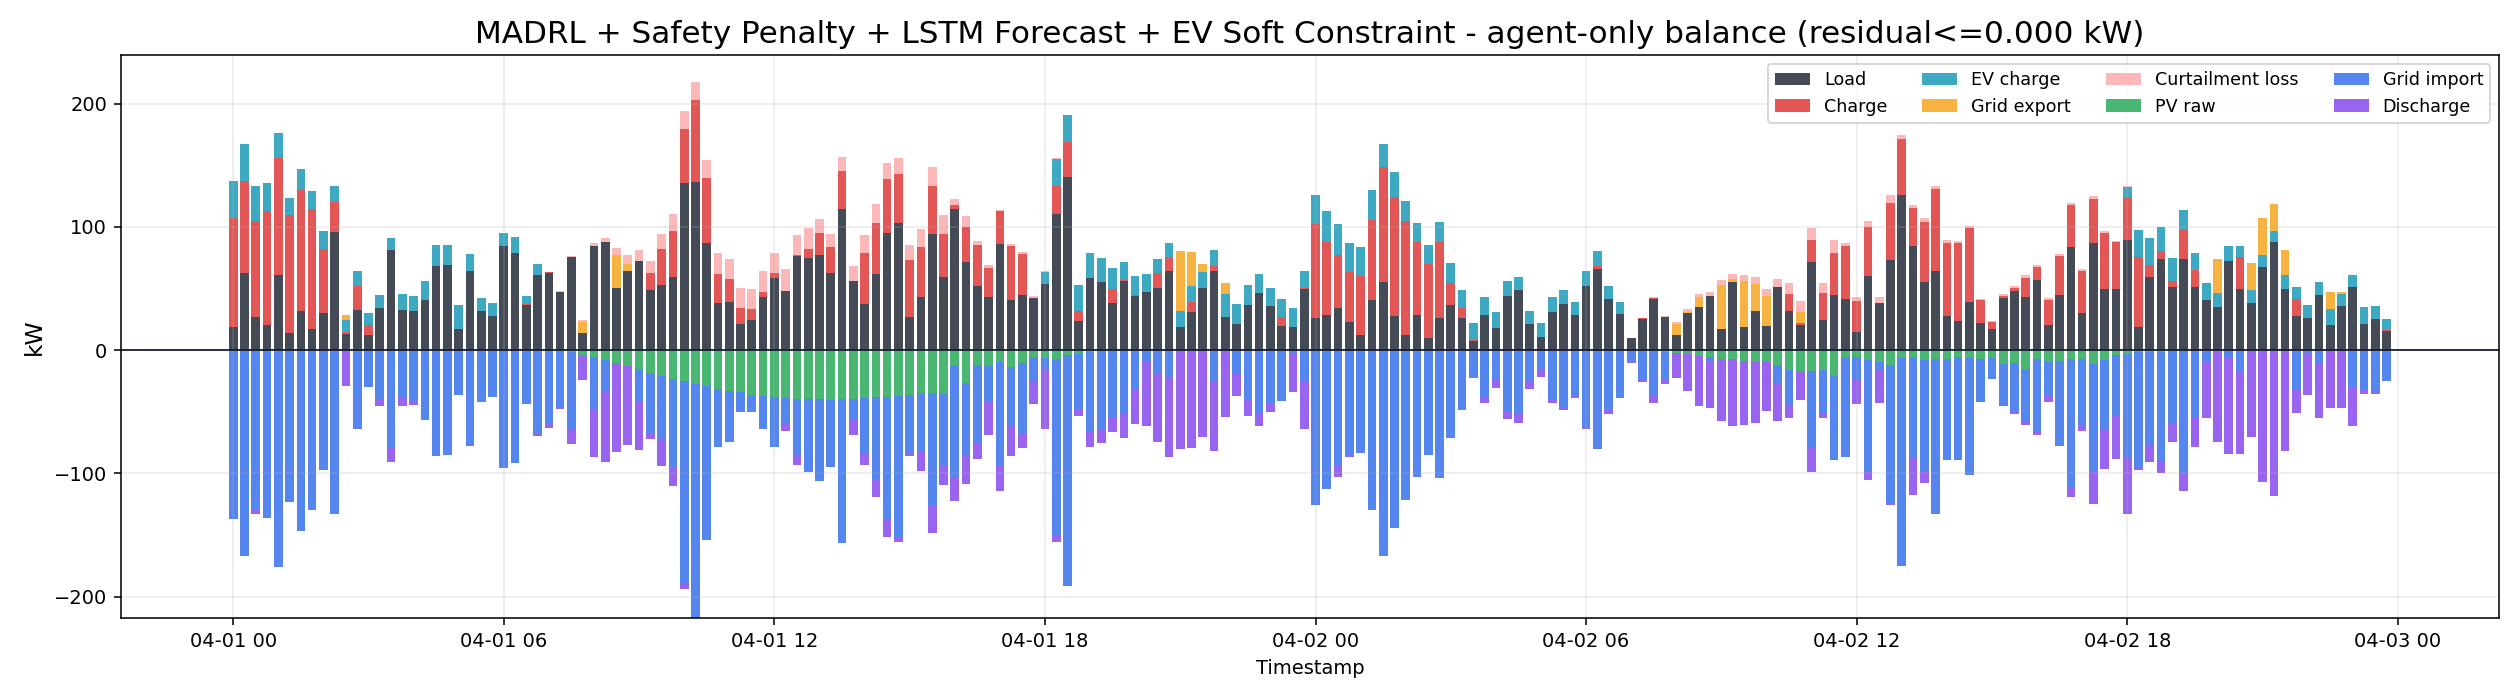

2. Price - EV soft constraint


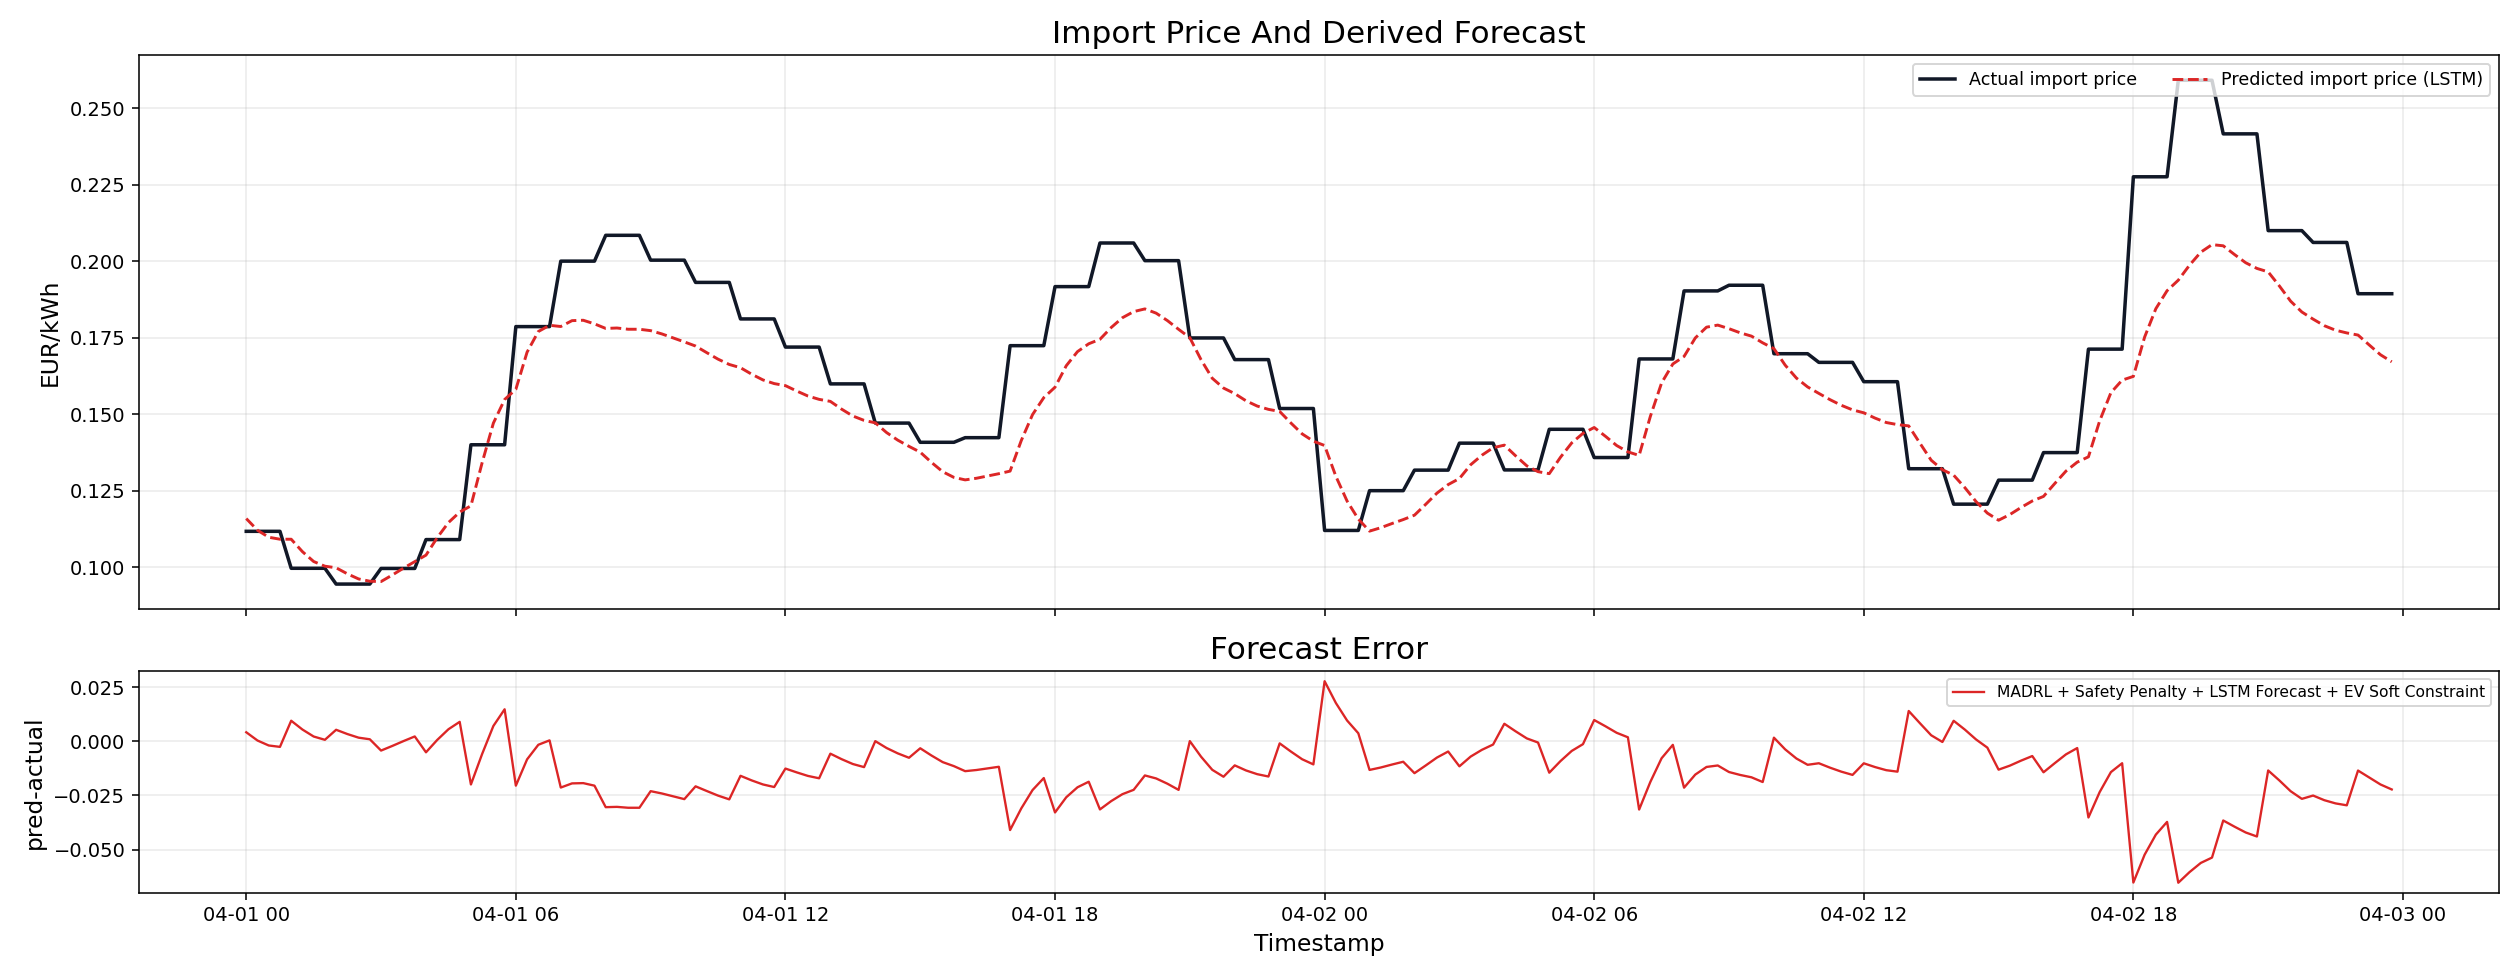

3. Battery power vs price - EV soft constraint


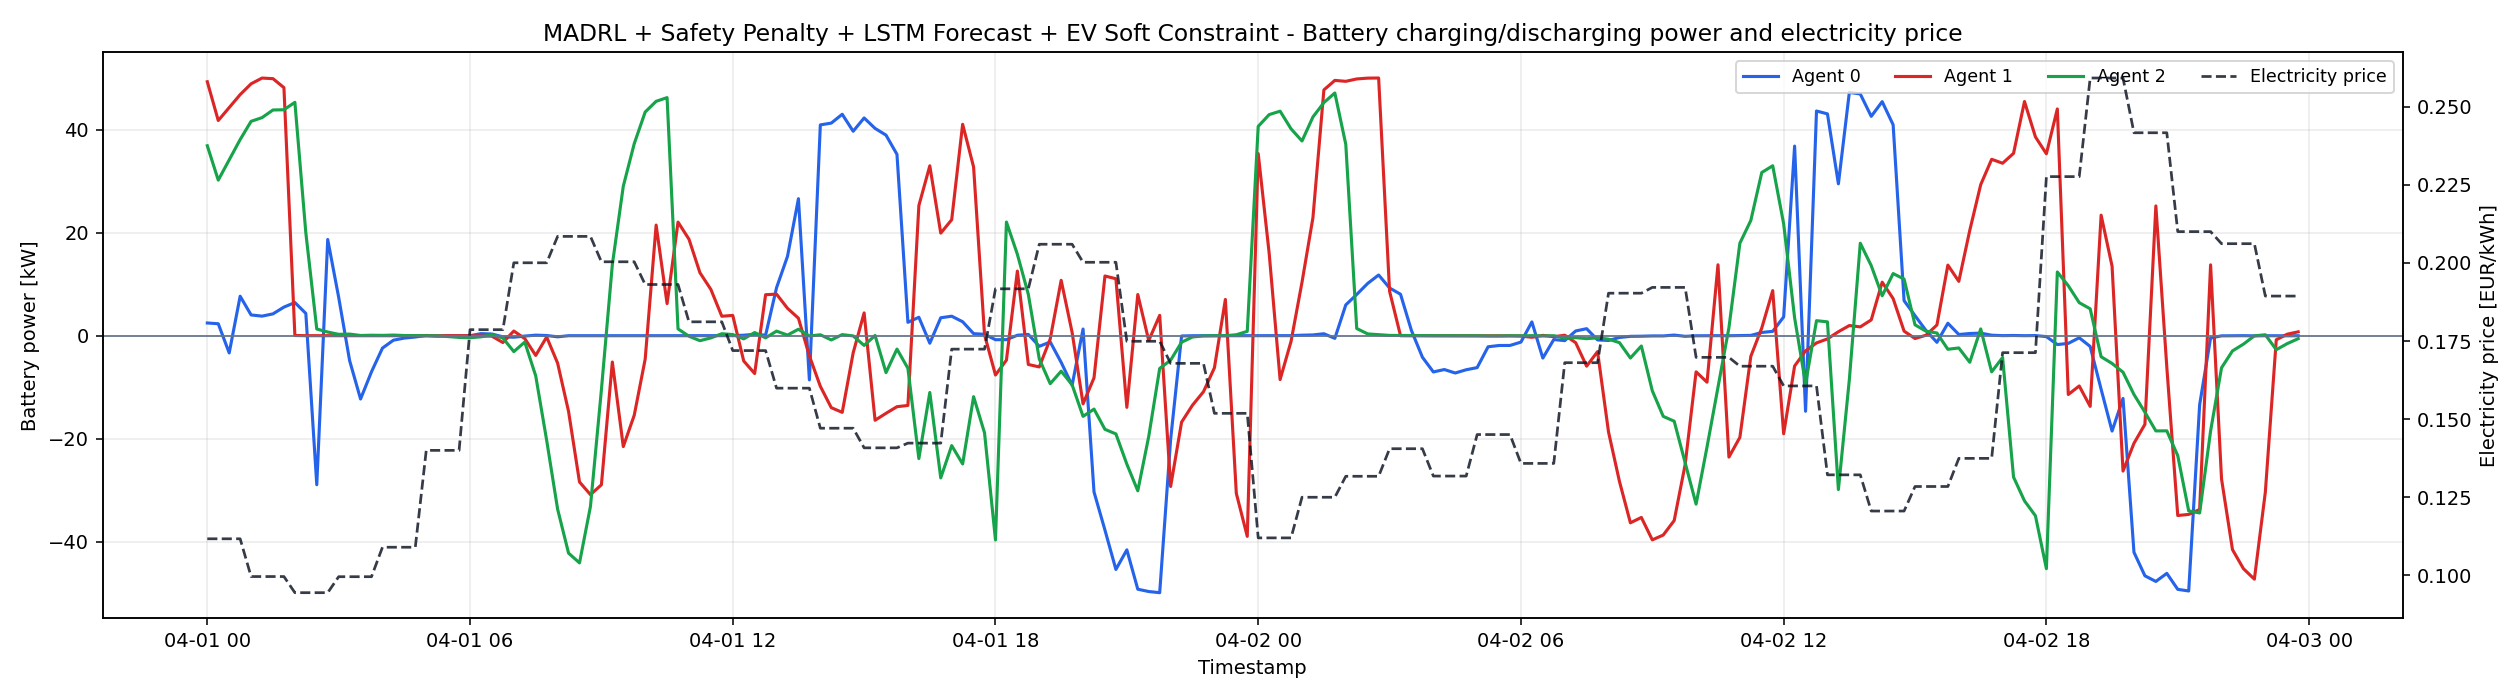

4. EV charging power vs price - EV soft constraint


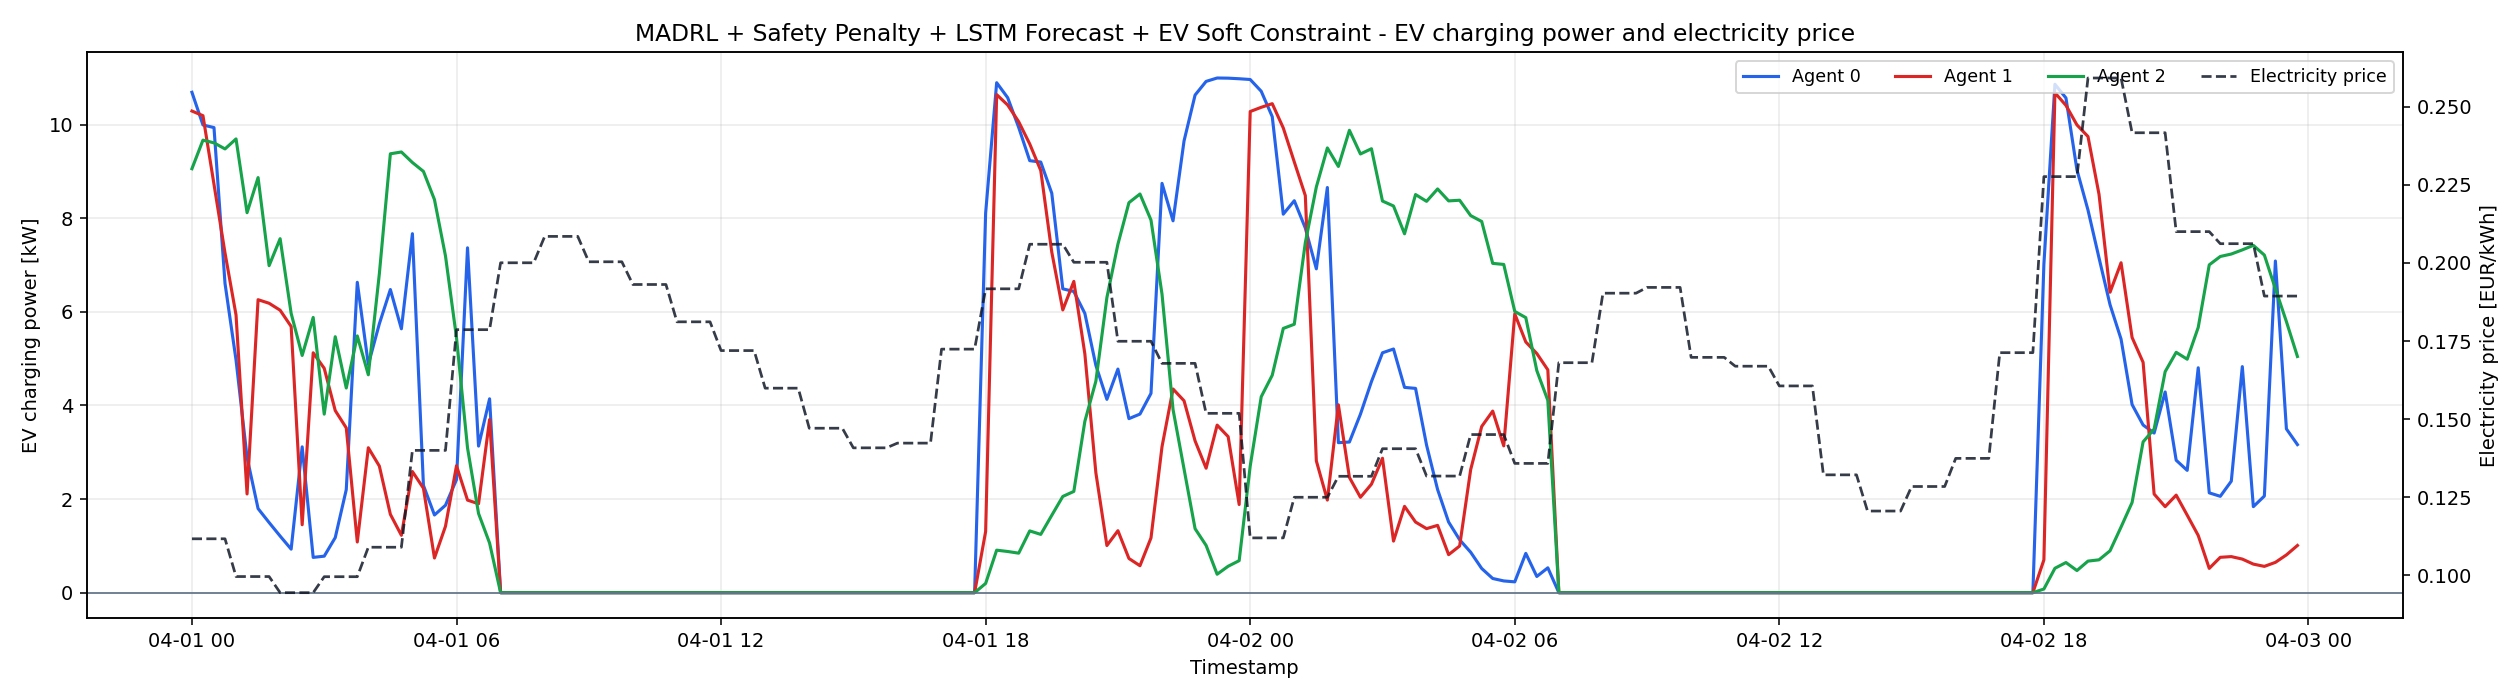

5. Total cumulative cost - EV soft constraint


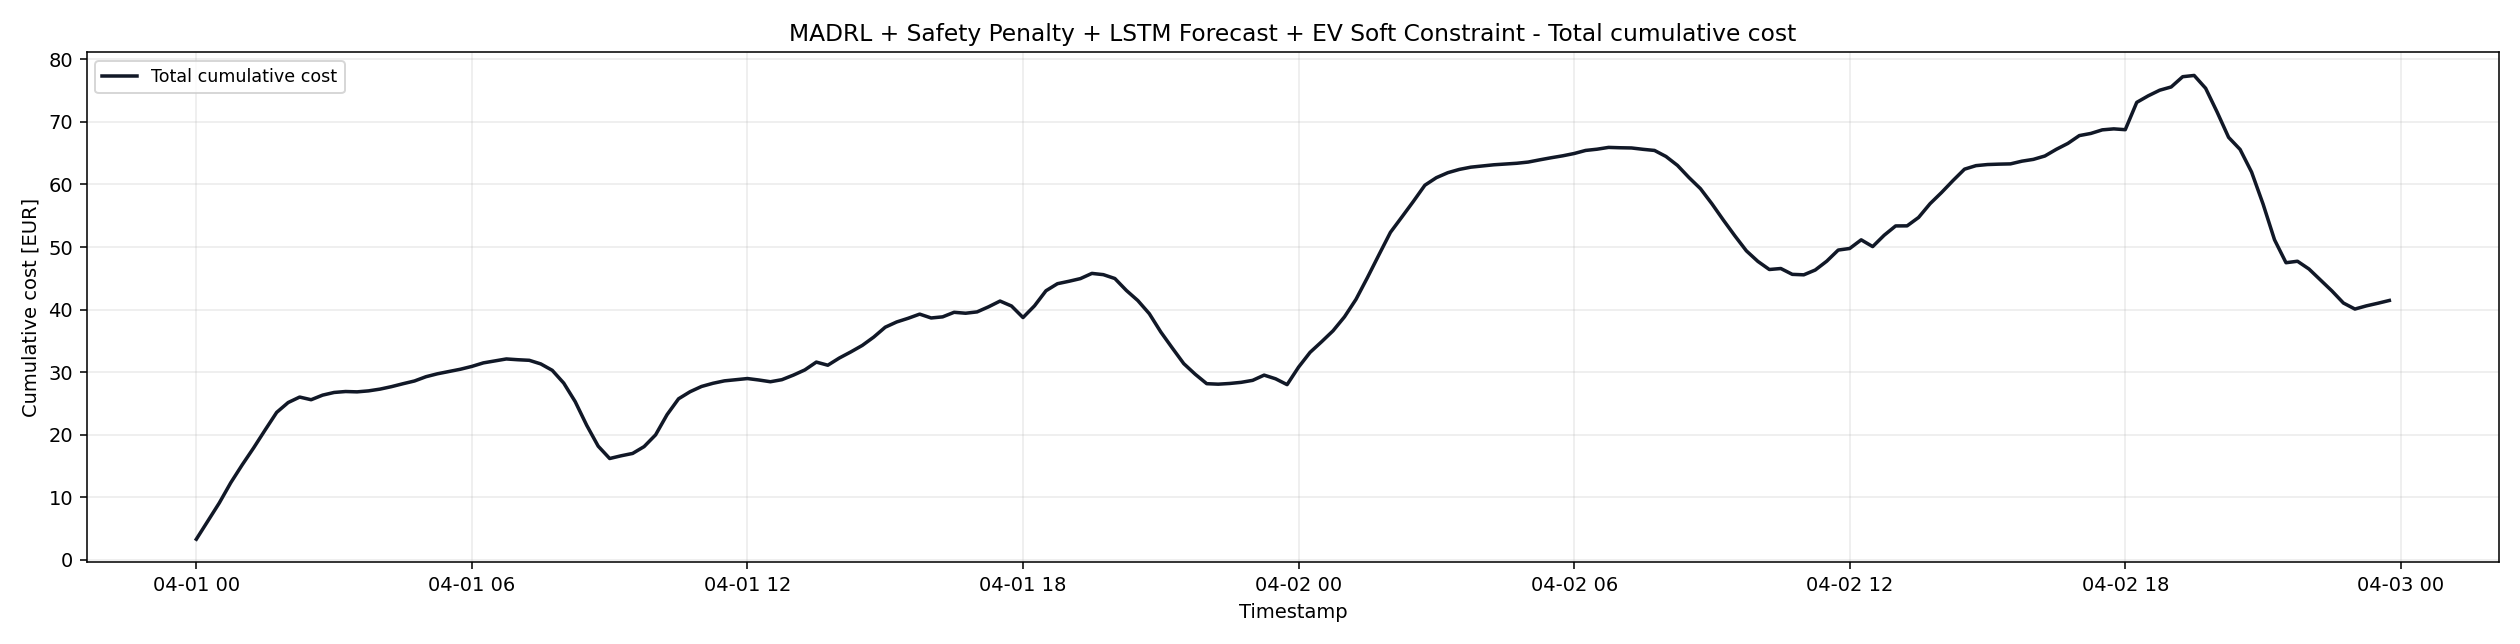

6. Cost components per step - EV soft constraint


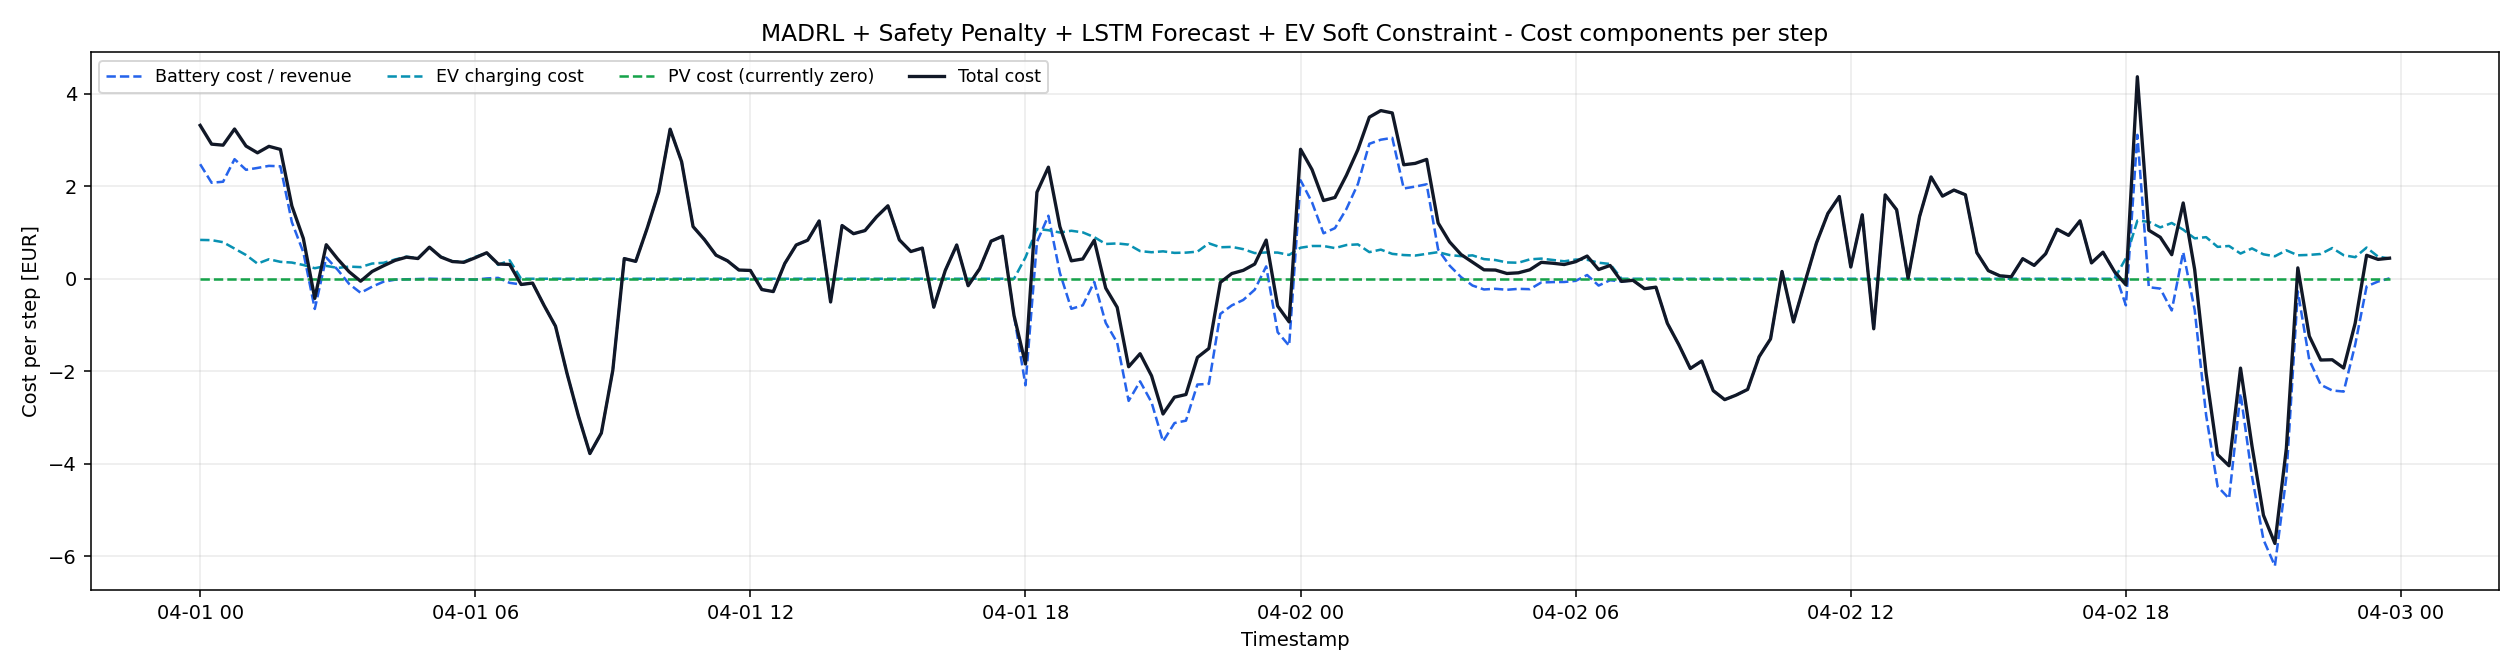

7. Cumulative cost components - EV soft constraint


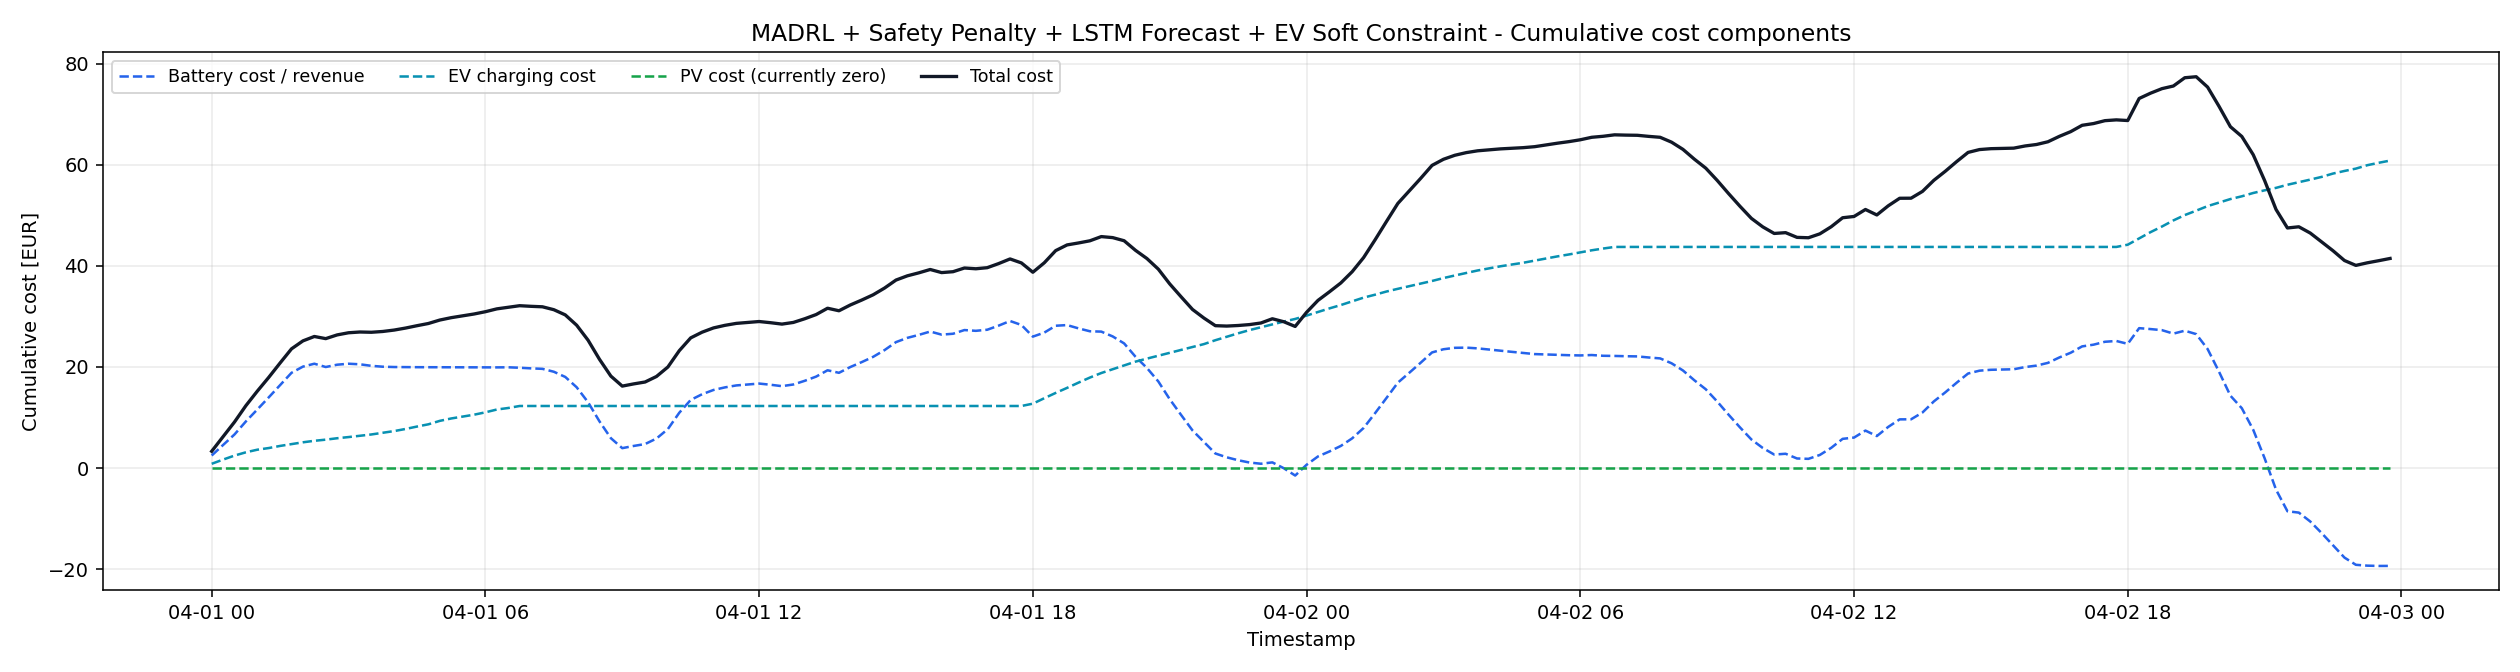

8. Battery power and SoC - EV soft constraint


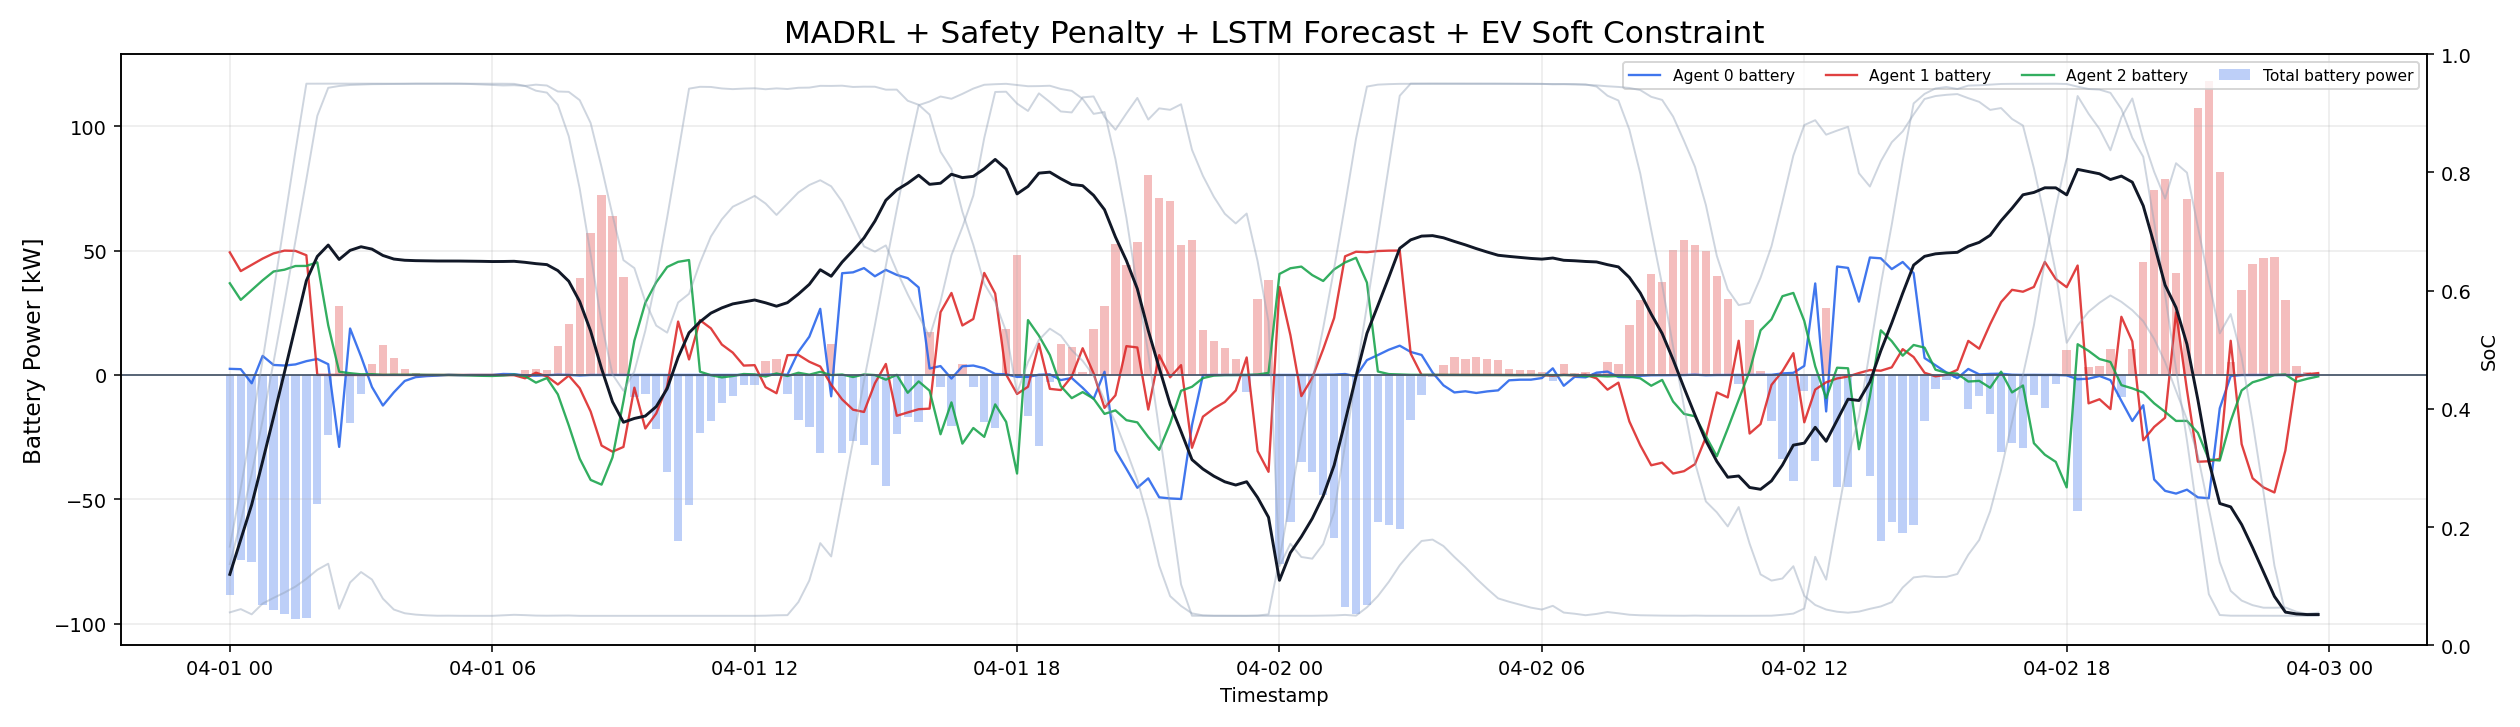

9. Voltage - EV soft constraint


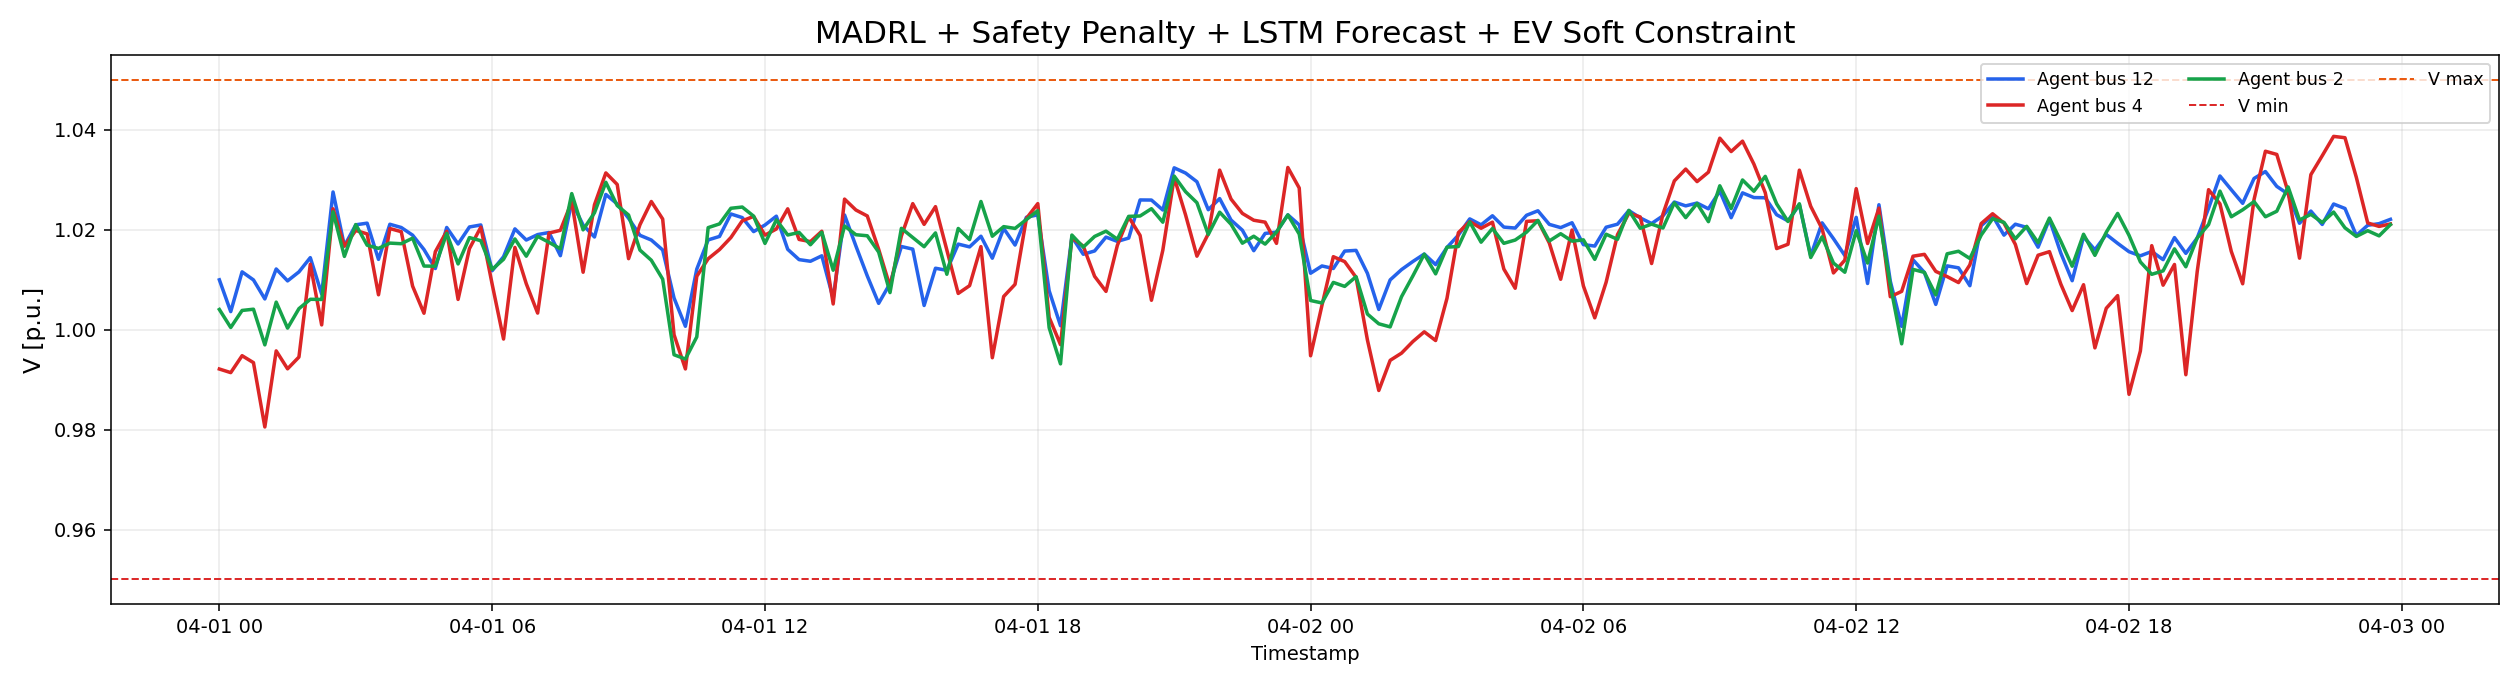

10. Net load - EV soft constraint


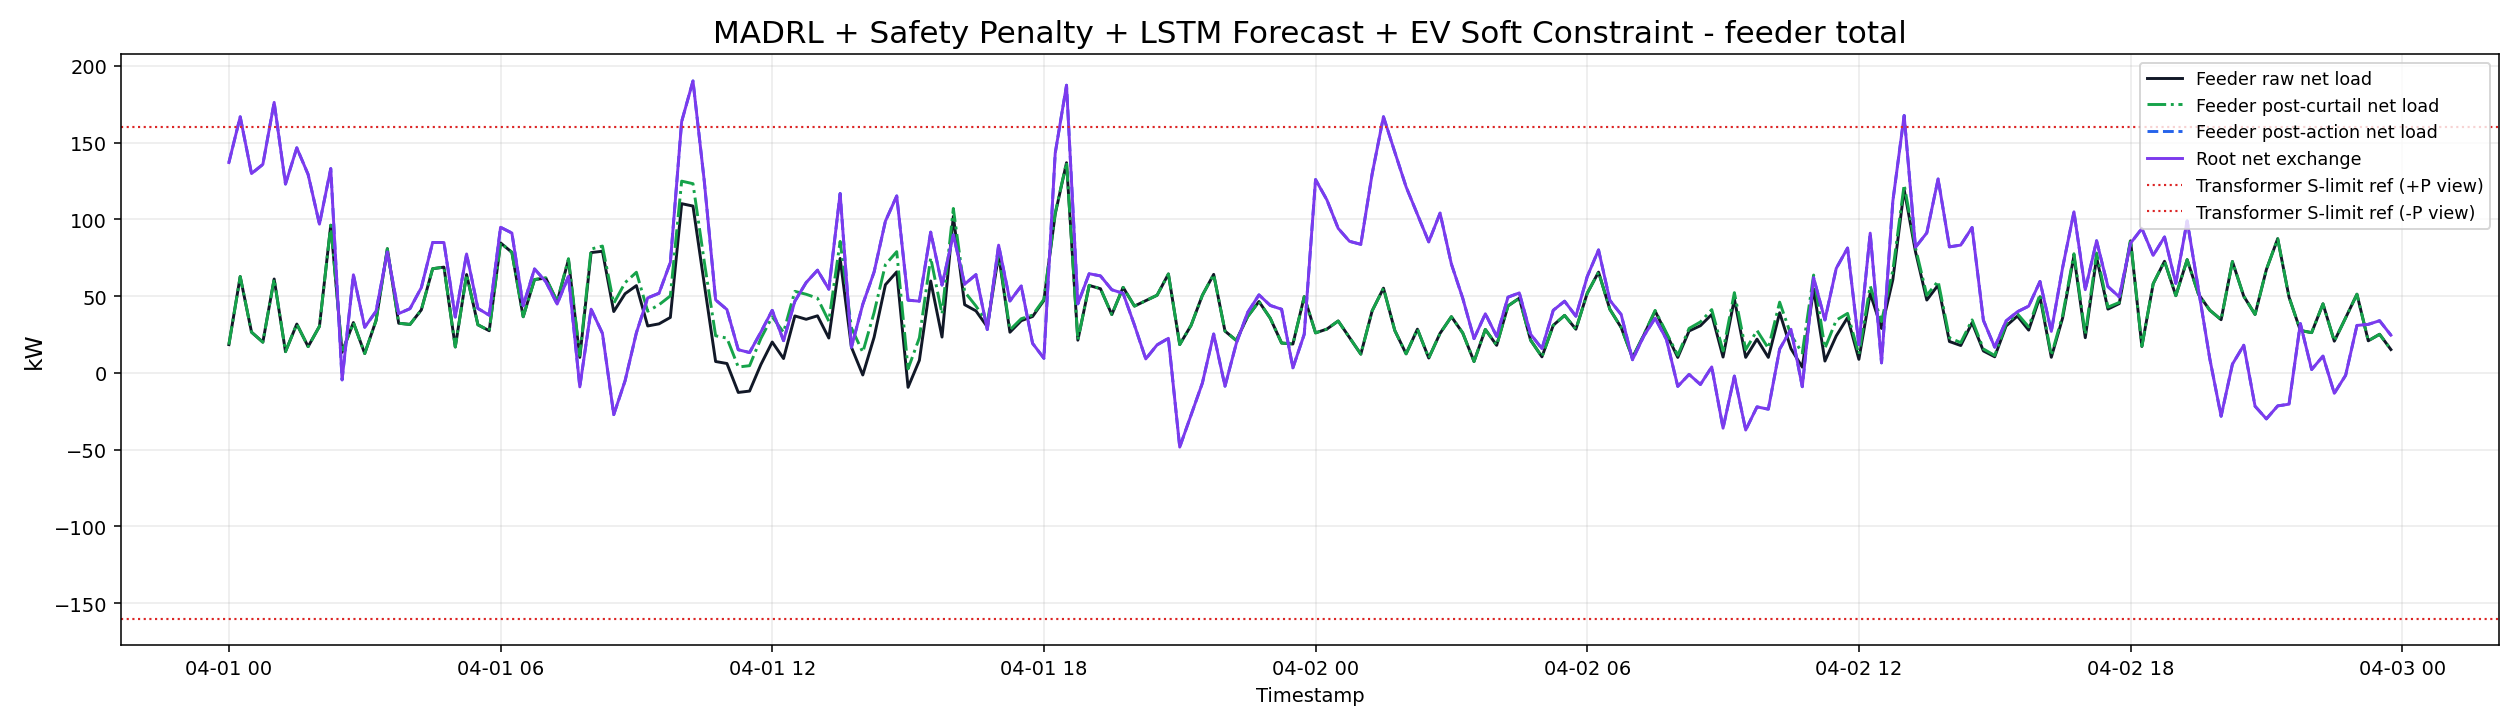

11. EV SOC - EV soft constraint


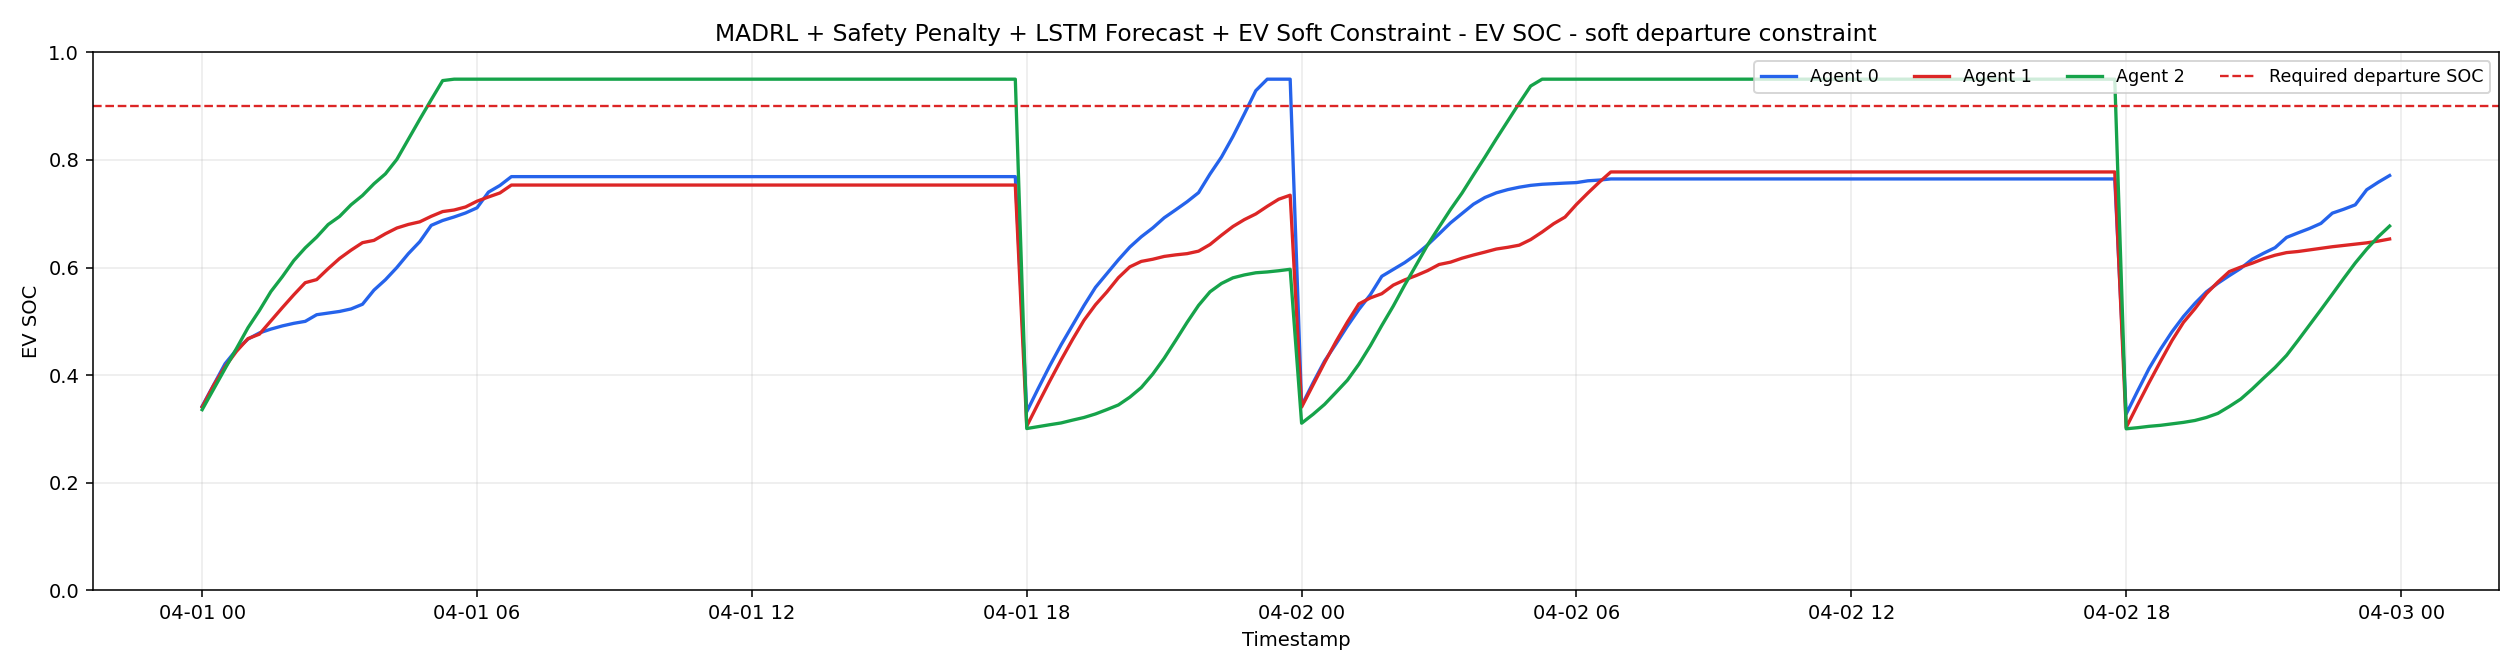

12. EV charging power - EV soft constraint


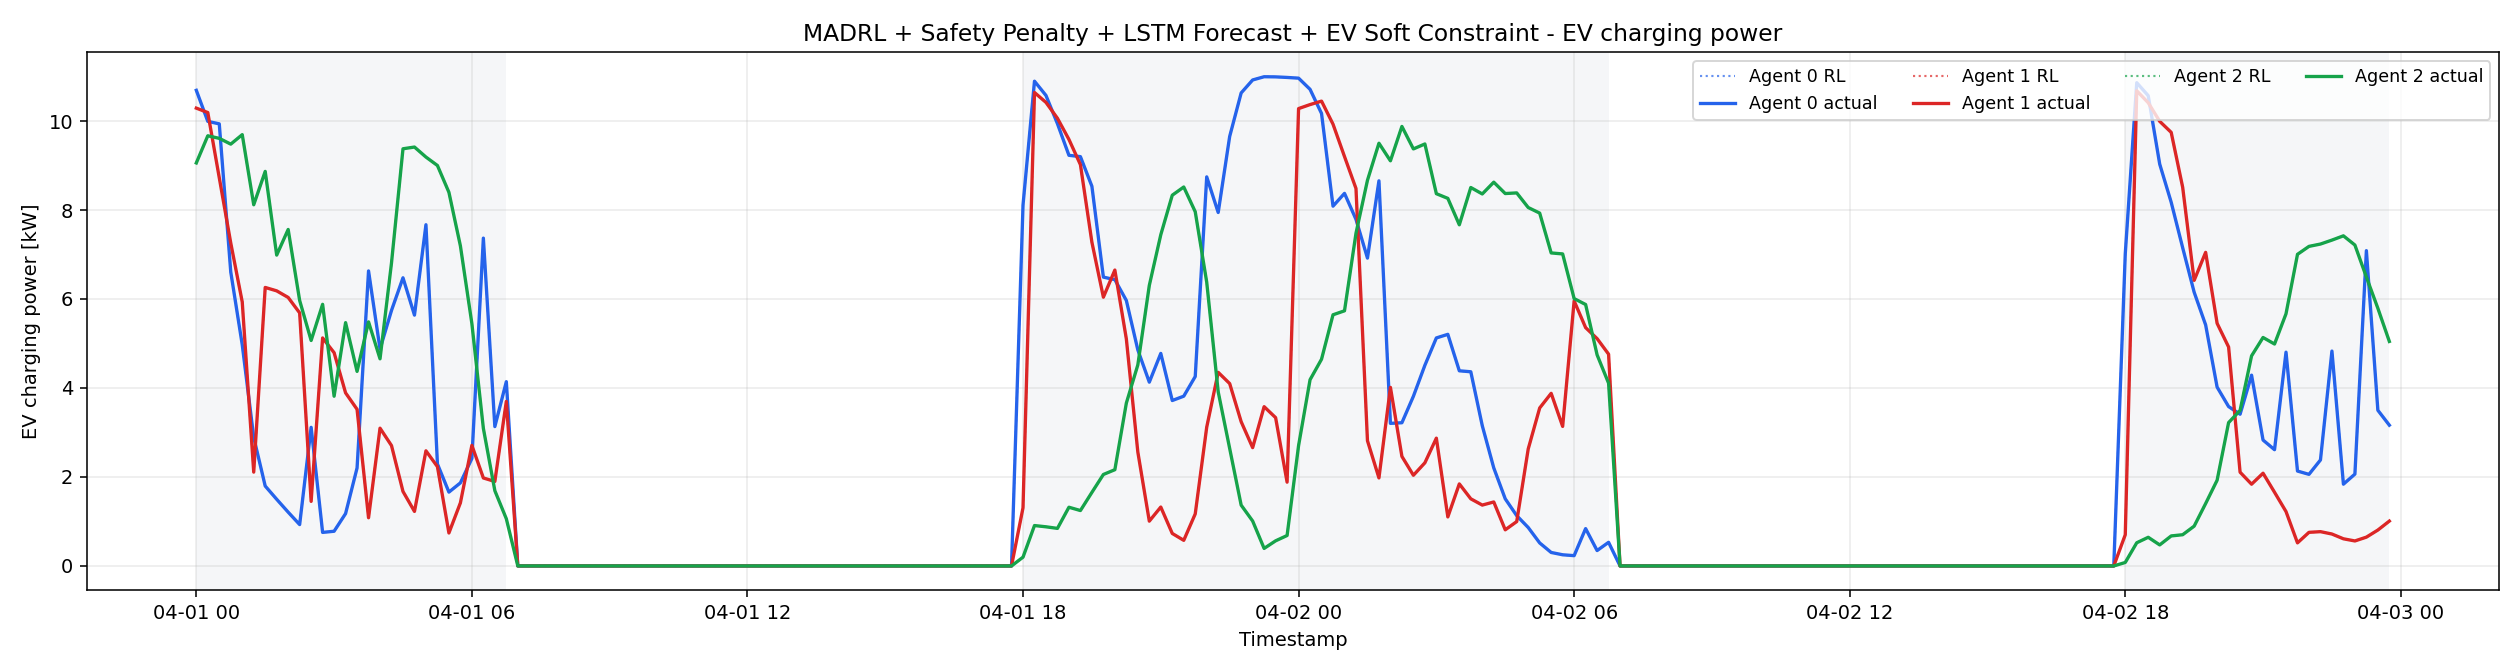

13. EV departure SOC requirement check - EV soft constraint


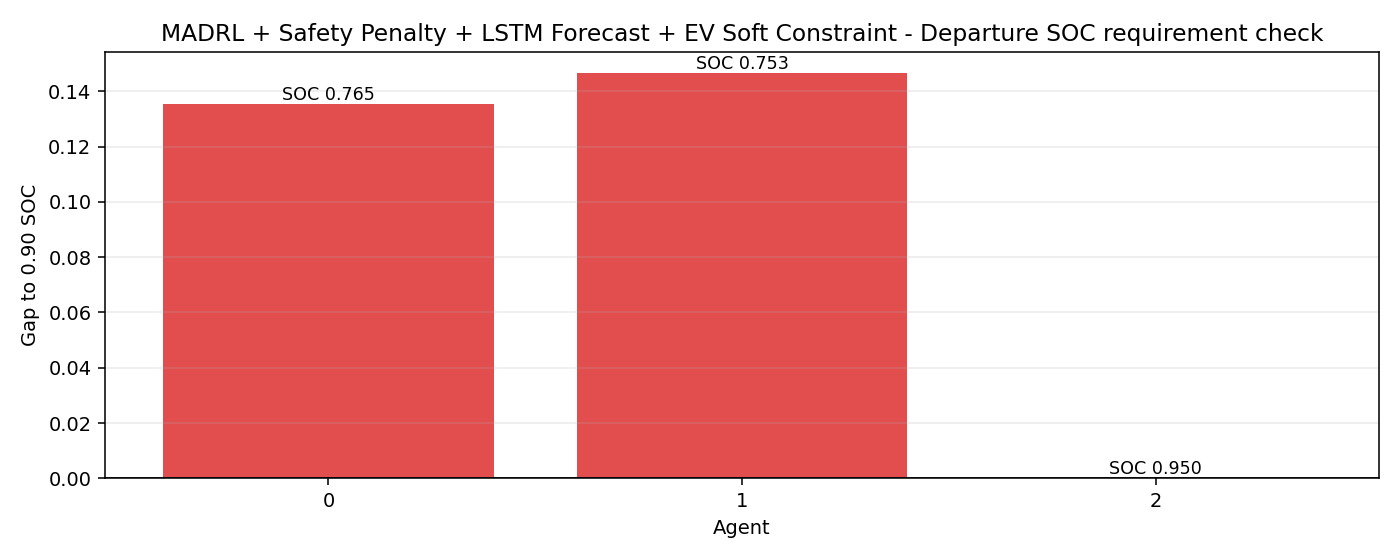

14. Training reward - EV soft constraint


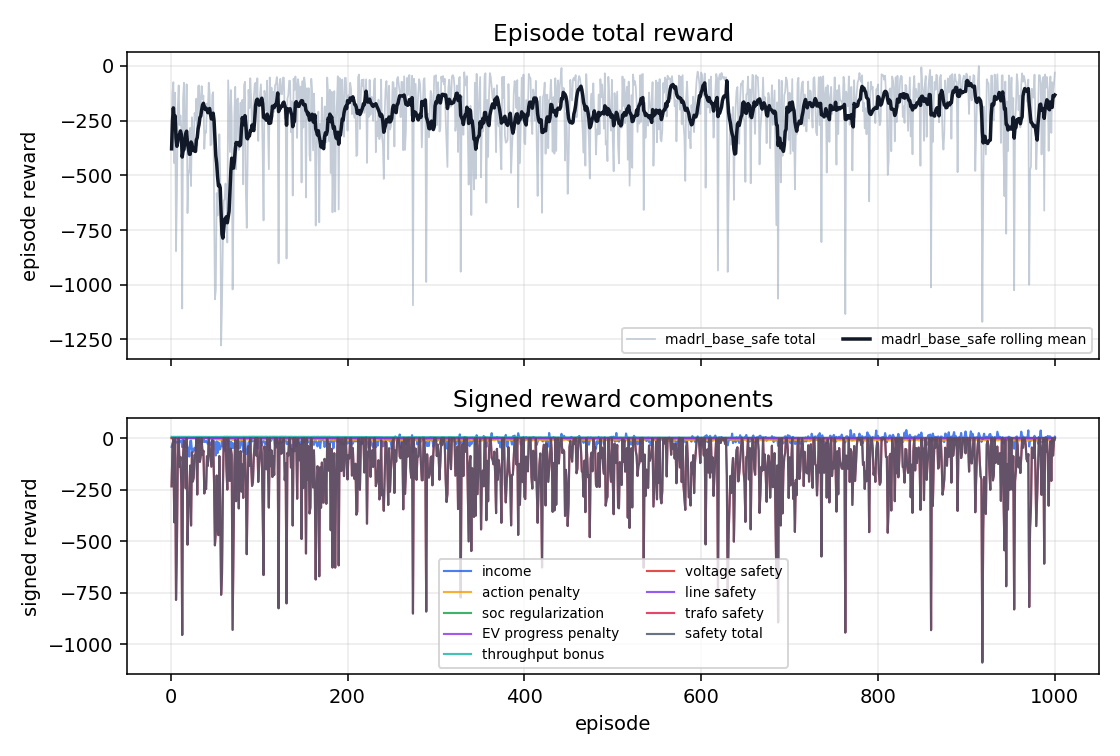

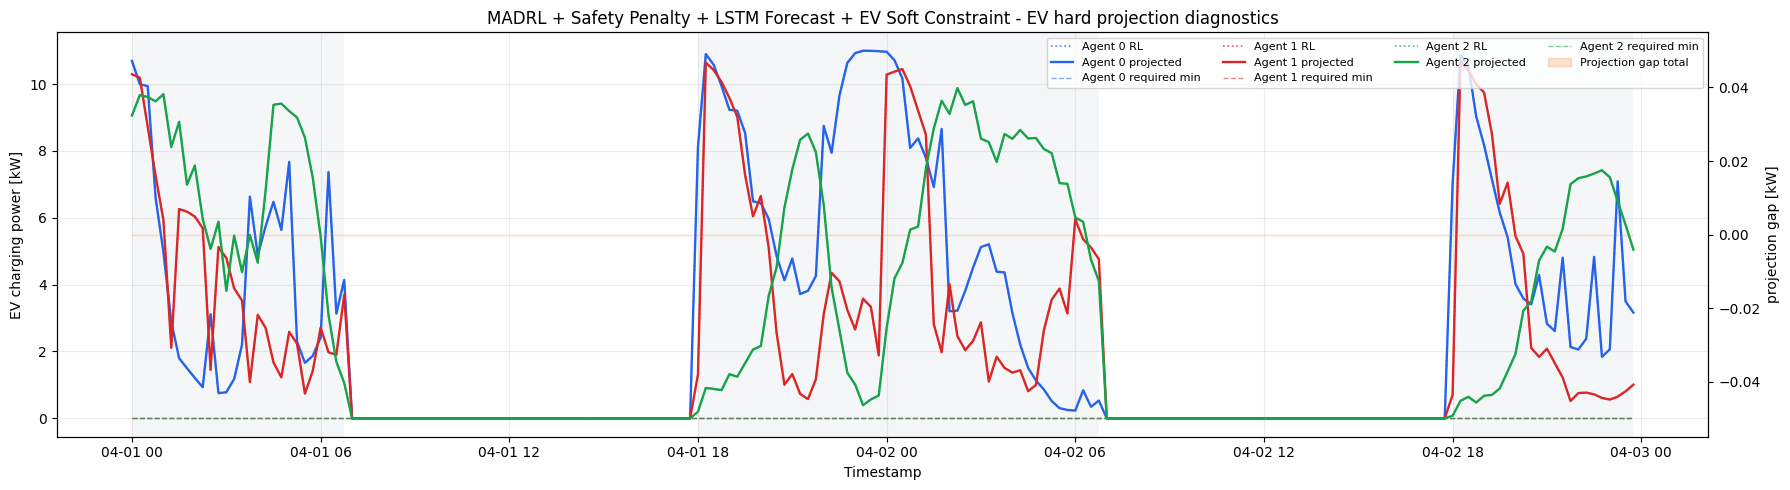

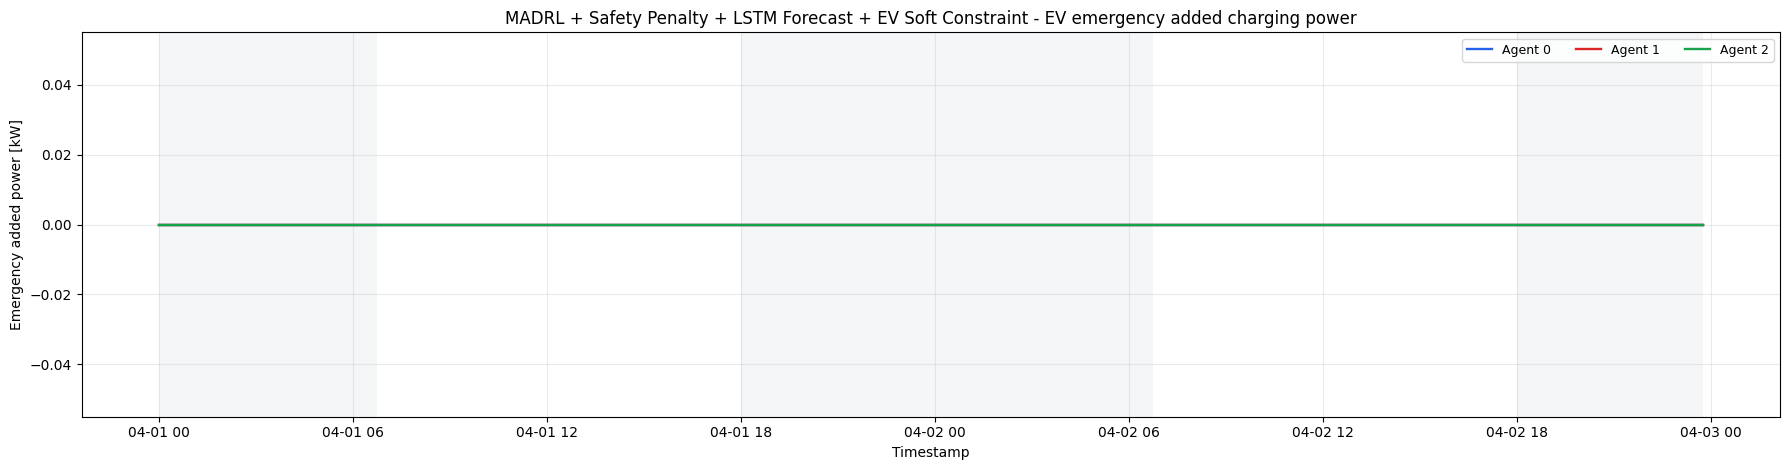

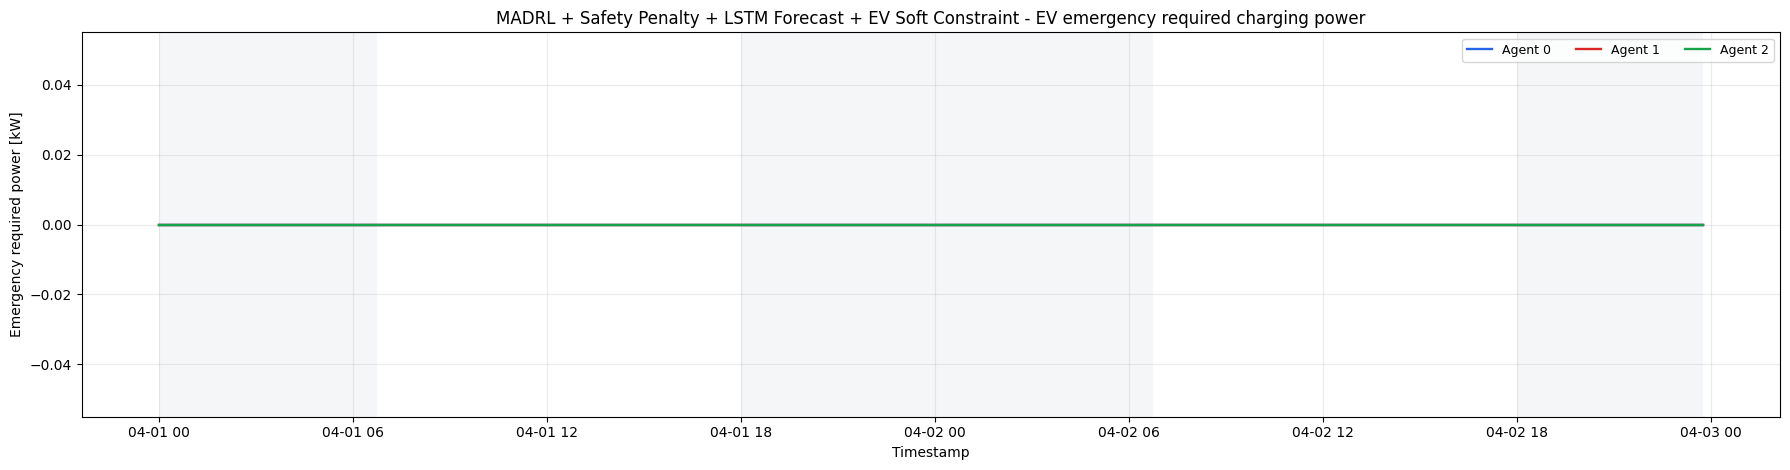

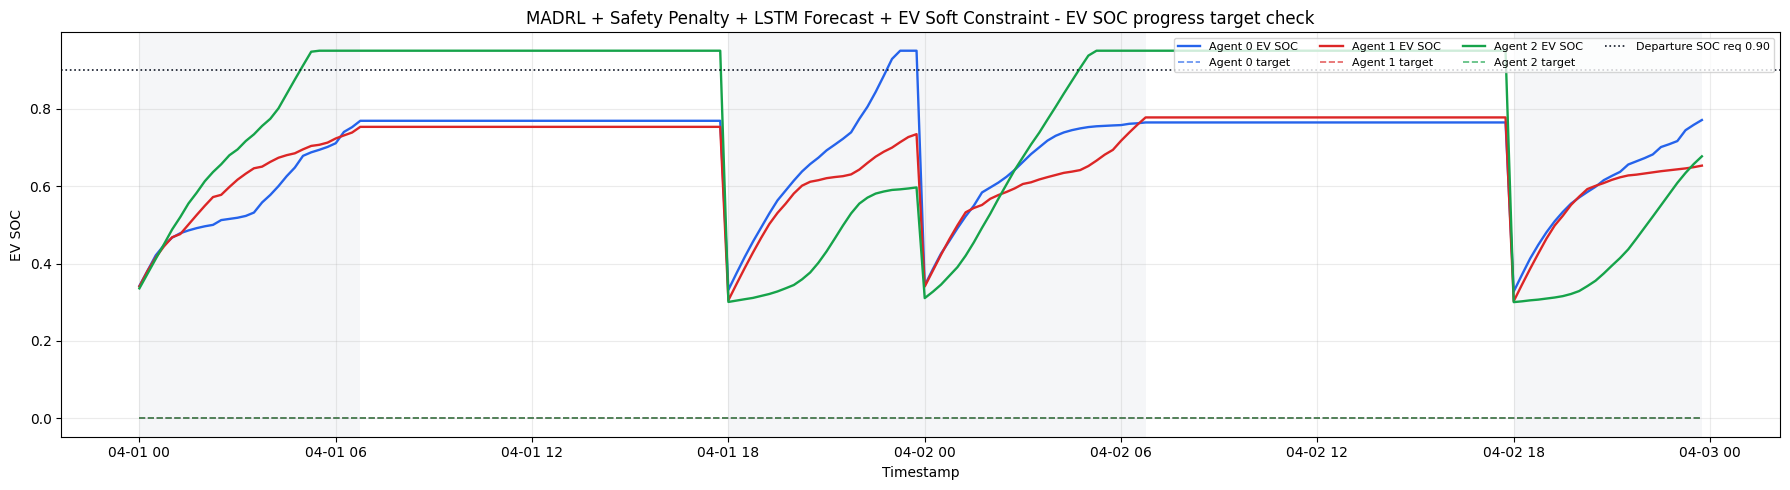

In [8]:
plt.close("all")
figures = plot_madrl_outputs(result, run_dir)
_plot_specs = [
    ("1. Power balance", "madrl_base_safe_power_balance"),
    ("2. Price", "madrl_base_safe_price"),
    ("3. Battery power vs price", "madrl_base_safe_battery_power_price"),
    ("4. EV charging power vs price", "madrl_base_safe_ev_charge_price"),
    ("5. Total cumulative cost", f"{scheme_name}_total_cost"),
    ("6. Cost components per step", f"{scheme_name}_cost_components"),
    ("7. Cumulative cost components", f"{scheme_name}_cumulative_cost_components"),
    ("8. Battery power and SoC", "madrl_base_safe_battery_soc"),
    ("9. Voltage", "madrl_base_safe_voltage"),
    ("10. Net load", "madrl_base_safe_net_load"),
    ("11. EV SOC", "madrl_base_safe_ev_soc"),
    ("12. EV charging power", "madrl_base_safe_ev_charge_kw"),
    ("13. EV departure SOC requirement check", "madrl_base_safe_ev_departure_check"),
    ("14. Training reward", "madrl_base_safe_learning_curve"),
]
for title, name in _plot_specs:
    path = run_dir / "figures" / f"{name}.png"
    if path.exists():
        print(f"{title} - EV soft constraint")
        display(Image(filename=str(path)))
        if name in figures:
            plt.close(figures[name])
    else:
        print(f"[missing] {title}: {path}")
